<a href="https://colab.research.google.com/github/rmarharyta/machinelearning/blob/main/%D0%A0%D1%83%D0%B1%D0%BB%D0%B5%D0%BD%D0%BA%D0%BE_%D0%9B%D0%A02_2_%D0%9A%D0%A1%D0%92%D0%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Авторка роботи: Рубленко Маргарита Віталіївна ФІТ 4-10**

Була присутня на парі

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("sootersaalu/amazon-top-50-bestselling-books-2009-2019")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-top-50-bestselling-books-2009-2019' dataset.
Path to dataset files: /kaggle/input/amazon-top-50-bestselling-books-2009-2019


In [ ]:
df = pd.read_csv(path + "/bestsellers with categories.csv")
df

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


Вивести перших 5 рядків

In [ ]:
df.head(5)

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


Вивести розмір датасету

In [ ]:
df.shape

(550, 7)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.duplicated(subset='Name').sum()

np.int64(199)

In [ ]:
df = df.drop_duplicates(subset='Name')
print("Complete")

Complete


In [ ]:
df.shape

(351, 7)

Датасет зберігає дані про 550 книг, з них 351 назва є унікальною.

Для кожної з книг є 7 змінних(колонок), розглянемо їх детальніше:

**Опис набору даних**

Набір містить 550 записів і 7 ознак та включає інформацію про популярні книги.

* **Name** — назва книги;
* **Author** — автор книги;
* **User Rating** — середня оцінка книги користувачами;
* **Reviews** — кількість відгуків користувачів;
* **Price** — ціна книги;
* **Year** — рік, у якому книга була представлена серед бестселерів;
* **Genre** — жанр книги: художня література (Fiction) або нехудожня література (Non Fiction).

In [ ]:
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']
df.head()

,name,author,user_rating,reviews,price,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


Перевірити дані у рядках

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 351 entries, 0 to 546
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         351 non-null    object 
 1   author       351 non-null    object 
 2   user_rating  351 non-null    float64
 3   reviews      351 non-null    int64  
 4   price        351 non-null    int64  
 5   year         351 non-null    int64  
 6   genre        351 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 21.9+ KB


In [ ]:
df.isna().sum()

,0
name,0
author,0
user_rating,0
reviews,0
price,0
year,0
genre,0


Перевірка унікальних значень в колонці `genre`

In [ ]:
df['genre'].value_counts()

,count
genre,
Non Fiction,191
Fiction,160


In [ ]:
df['genre'].unique()

array(['Non Fiction', 'Fiction'], dtype=object)

Розподіл цін. Побудова діаграми

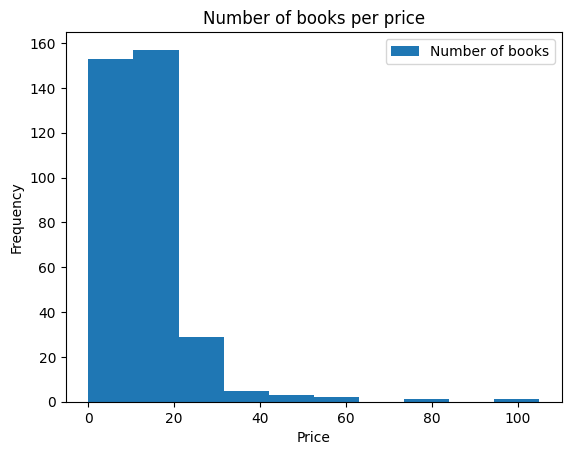

In [ ]:
df['price'].plot(kind = 'hist', label = 'Number of books')
plt.xlabel('Price')
plt.title('Number of books per price')
plt.legend()
plt.show()

Визначити максимальну, мінімальну, середню ціни та медіану.

In [ ]:
df['price'].describe()

,price
count,351.000000
mean,13.076923
std,10.050860
min,0.000000
25%,8.000000
50%,12.000000
75%,16.000000
max,105.000000


In [ ]:
a = df['price'].max()
b = df['price'].min()
c = df['price'].mean()
d = df['price'].median()
print("Max =",  a)
print("Min =", b)
print("Mean =", c)
print("Median =", d)

Max = 105
Min = 0
Mean = 13.076923076923077
Median = 12.0


* Максимальна ціна - 105
* Мінімальна ціна - 0
* Середня ціна - 13.07
* Медіана цін - 12

Визначити який рейтинг у датасеті найвищий?

In [ ]:
df['user_rating'].max()

4.9

Скільки книг мають такий рейтинг?

In [ ]:
print(df[df['user_rating'] == 4.9]['name'].count())

28


У якої книги найбільше відгуків?

In [ ]:
df[df['reviews'] == df['reviews'].max()]

,name,author,user_rating,reviews,price,year,genre
534,Where the Crawdads Sing,Delia Owens,4.8,87841,15,2019,Fiction


З тих книг, що потрапили до Топ-50 у 2015 році, яка книга найдорожча?

In [ ]:
max_price = df[df['year'] == 2015]['price'].max()
df[(df['year'] == 2015) & (df['price'] == max_price)]

,name,author,user_rating,reviews,price,year,genre
132,Go Set a Watchman: A Novel,Harper Lee,3.6,14982,19,2015,Fiction


Скільки книг жанру Fiction потрапили до Топ-50 у 2010 році?

In [ ]:
print(df[(df['year'] == 2010) & (df['genre'] == 'Fiction')].count()['name'])

17


Скільки книг з рейтингом 4.9 потрапило до рейтингу у 2010 та 2011 роках?

In [ ]:
df[(df['user_rating'] == 4.9) & ((df['year']==2010) | (df['year']==2011))]

,name,author,user_rating,reviews,price,year,genre
187,Jesus Calling: Enjoying Peace in His Presence ...,Sarah Young,4.9,19576,8,2011,Non Fiction


Сортування книг за зростанням ціни, котрі потрапили до рейтингу в 2015 році і коштують дешевше за 8 доларів.

In [ ]:
df[(df['price'] < 8) & (df['year'] == 2015)].sort_values('price')

,name,author,user_rating,reviews,price,year,genre
54,Creative Haven Creative Cats Coloring Book (Ad...,Marjorie Sarnat,4.8,4022,4,2015,Non Fiction
123,Giraffes Can't Dance,Giles Andreae,4.8,14038,4,2015,Fiction
55,Creative Haven Owls Coloring Book (Adult Color...,Marjorie Sarnat,4.8,3871,5,2015,Non Fiction
28,Baby Touch and Feel: Animals,DK,4.6,5360,5,2015,Non Fiction
63,Dear Zoo: A Lift-the-Flap Book,Rod Campbell,4.8,10922,5,2015,Fiction
89,Dover Creative Haven Art Nouveau Animal Design...,Marty Noble,4.6,2134,5,2015,Non Fiction
201,Killing Reagan: The Violent Assault That Chang...,Bill O'Reilly,4.6,5235,5,2015,Non Fiction
16,Adult Coloring Book: Stress Relieving Animal D...,Blue Star Coloring,4.6,2925,6,2015,Non Fiction
17,Adult Coloring Book: Stress Relieving Patterns,Blue Star Coloring,4.4,2951,6,2015,Non Fiction
253,Old School (Diary of a Wimpy Kid #10),Jeff Kinney,4.8,6169,7,2015,Fiction


Максимальна та мінімальна ціна для всіх жанрів

In [ ]:
df.groupby(['genre'])[['price']].agg([np.min, np.max])

/tmp/ipykernel_2587/1401501477.py:1: FutureWarning: The provided callable <function min at 0x7fbe187936a0> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  df.groupby(['genre'])[['price']].agg([np.min, np.max])
/tmp/ipykernel_2587/1401501477.py:1: FutureWarning: The provided callable <function max at 0x7fbe18793560> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df.groupby(['genre'])[['price']].agg([np.min, np.max])


price     
              min  max
genre                 
Fiction         0   82
Non Fiction     0  105

Створити новий датафрейм, який вміщатиме кількість книг для кожного з авторів

In [ ]:
author_books = df.groupby(['author'])[['name']].count()
author_books

,name
author,
Abraham Verghese,1
Adam Gasiewski,1
Adam Mansbach,1
Adir Levy,1
Admiral William H. McRaven,1
...,...
Walter Isaacson,2
William Davis,1
William P. Young,1
